# Setup

In [35]:
import os, csv, json, random, tarfile, subprocess
import collections, re
from dataclasses import dataclass
import numpy as np
import pandas as pd
from tqdm import tqdm
import torchaudio
import matplotlib.pyplot as plt
from typing import Optional
import urllib.request, urllib.error
import unicodedata

In [ ]:
os.environ["CV_API_KEY"] = "DO_NOT_FORGET_TO_PUT_KEY_HERE"

In [5]:
@dataclass
class ExperimentConfig:
    data_dir: str = "/content/data"
    cv_api_key: str = ""
    cv_dataset_id: str = "cmj8u3pys00t5nxxb56wugqgq"
    cv_tarball_name: str = "Common Voice Scripted Speech 24.0 - Ukrainian.tar.gz"

# Data Loading

In [7]:
def _find_extracted_root(data_dir: str) -> Optional[str]:
    for root, dirs, files in os.walk(data_dir):
        if "train.tsv" in files and "clips" in dirs:
            return root
    return None

def download_common_voice(cfg: ExperimentConfig) -> str:
    tarball_path = os.path.join(cfg.data_dir, cfg.cv_tarball_name)
    os.makedirs(cfg.data_dir, exist_ok=True)

    extracted_root = _find_extracted_root(cfg.data_dir)
    if extracted_root is not None:
        print(f"Dataset already extracted at: {extracted_root}")
        return extracted_root

    if not os.path.exists(tarball_path):
        api_key = cfg.cv_api_key or os.environ.get("CV_API_KEY", "")
        if not api_key:
            raise ValueError("No API key provided")

        print("Requesting download URL from Mozilla datacollective API...")

        req = urllib.request.Request(
            f"https://datacollective.mozillafoundation.org/api/datasets/{cfg.cv_dataset_id}/download",
            method="POST",
            headers={
                "Authorization": f"Bearer {api_key}",
                "Content-Type": "application/json",
            },
        )

        try:
            with urllib.request.urlopen(req) as resp:
                body = json.loads(resp.read().decode())
            download_url = body["downloadUrl"]
        except (urllib.error.HTTPError, KeyError) as e:
            raise RuntimeError(f"Failed to get download URL: {e}") from e

        print(f"Downloading {cfg.cv_tarball_name} ...")
        subprocess.run(["curl", "-L", "-o", tarball_path, download_url], check=True)
        print(f"Downloaded to {tarball_path} ({os.path.getsize(tarball_path) / 1e9:.2f} GB)")
    else:
        print(f"Tarball already exists: {tarball_path}")

    print("Extracting tarball...")
    with tarfile.open(tarball_path, "r:gz") as tar:
        tar.extractall(path=cfg.data_dir)
    print("Extraction complete")

    extracted_root = _find_extracted_root(cfg.data_dir)
    if extracted_root is None:
        raise FileNotFoundError(f"Could not find extracted dataset with 'clips' folder in {cfg.data_dir}")

    print(f"Dataset root: {extracted_root}")
    return extracted_root

In [8]:
cfg = ExperimentConfig()
root = download_common_voice(cfg)
clips_dir = os.path.join(root, "clips")

Requesting download URL from Mozilla datacollective API...
Downloaded to /content/data/Common Voice Scripted Speech 24.0 - Ukrainian.tar.gz (2.75 GB)
Extracting tarball...


/tmp/ipython-input-1771853720.py:47: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=cfg.data_dir)


Extraction complete
Dataset root: /content/data/cv-corpus-24.0-2025-12-05/uk


In [41]:
def read_cv_tsv(tsv_path: str) -> pd.DataFrame:
    df = pd.read_csv(tsv_path, sep="\t", quoting=csv.QUOTE_NONE, low_memory=False)
    df["path"] = df["path"].astype(str).apply(lambda x: x if x.endswith(".mp3") else x + ".mp3")
    return df

train_df = read_cv_tsv(os.path.join(root, "train.tsv"))
dev_df = read_cv_tsv(os.path.join(root, "dev.tsv")) if os.path.isfile(os.path.join(root, "dev.tsv")) else pd.DataFrame()
test_df = read_cv_tsv(os.path.join(root, "test.tsv"))

print("Raw rows:", {"train": len(train_df), "dev": len(dev_df), "test": len(test_df)})
print("Train columns:", list(train_df.columns))

Raw rows: {'train': 27058, 'dev': 10297, 'test': 10295}
Train columns: ['client_id', 'path', 'sentence_id', 'sentence', 'sentence_domain', 'up_votes', 'down_votes', 'age', 'gender', 'accents', 'variant', 'locale', 'segment']


In [11]:
train_df.head(3)

,client_id,path,sentence_id,sentence,sentence_domain,up_votes,down_votes,age,gender,accents,variant,locale,segment
0,a3428c7fcafc7c12bbef4e320691b3fe9a68395f288d29...,common_voice_uk_23807857.mp3,1261dae931dca97c3b7384d7be2c510300c13eacc2a173...,— Була-м у городі. Не пускають мене за засіки.,NaN,2,1,twenties,female_feminine,NaN,NaN,uk,NaN
1,a3428c7fcafc7c12bbef4e320691b3fe9a68395f288d29...,common_voice_uk_23807858.mp3,a94dbd8a2aaa054dd86d252c4d40a5316f5eccc03b45a5...,"Ардарік, здибивши свого розпашілого чорного ко...",NaN,2,1,twenties,female_feminine,NaN,NaN,uk,NaN
2,a3428c7fcafc7c12bbef4e320691b3fe9a68395f288d29...,common_voice_uk_23807859.mp3,83e2905fa1d04c38d532318a9af08813c8469725e754b9...,"Вишата прокліпався й устав на рівні ноги, широ...",NaN,2,1,twenties,female_feminine,NaN,NaN,uk,NaN


# Text Normalization + Character Inventory

In [26]:
# allowed charset
# keep only Ukrainian letters + space + apostrophe
UK_LETTERS = "абвгґдеєжзиіїйклмнопрстуфхцчшщьюя"
ALLOWED_CHARS = set(" " + "'" + UK_LETTERS)

# unify common apostrophe-like chars into ASCII apostrophe
APOS_VARIANTS = {
    "\u2019": "'", # right single quotation mark
    "\u02bc": "'", # modifier letter apostrophe
    "\u2018": "'", # left single quotation mark
    "՚": "'", # armenian apostrophe-like
    "ʼ": "'", # modifier letter apostrophe
}

def normalize_for_audit(s: str) -> str:
    """lowercase + unify apostrophes + collapse spaces"""
    if not isinstance(s, str):
        return ""
    s = s.strip().lower()
    for k, v in APOS_VARIANTS.items():
        s = s.replace(k, v)
    s = re.sub(r"\s+", " ", s)
    return s

def add_text_cols(df: pd.DataFrame, text_col: str = "sentence") -> pd.DataFrame:
    """add normalized text + basic lengths"""
    df = df.copy()
    if text_col not in df.columns:
        df["sentence_norm"] = ""
    else:
        df["sentence_norm"] = df[text_col].apply(normalize_for_audit)
    df["n_chars"] = df["sentence_norm"].astype(str).str.len()
    df["n_words"] = df["sentence_norm"].astype(str).apply(lambda x: len(x.split()) if x else 0)
    return df

train_df = add_text_cols(train_df)
dev_df = add_text_cols(dev_df) if len(dev_df) else dev_df
test_df = add_text_cols(test_df)

In [31]:
# audit: characters outside allowed set
def extract_disallowed_chars(s: str) -> list[str]:
    return [ch for ch in s if ch not in ALLOWED_CHARS]

def build_disallowed_counter(series: pd.Series) -> collections.Counter:
    counter = collections.Counter()
    for s in series.astype(str):
        counter.update(extract_disallowed_chars(s))
    return counter

disallowed_counter = build_disallowed_counter(train_df["sentence_norm"])

train_df["has_disallowed"] = train_df["sentence_norm"].astype(str).apply(
    lambda s: any(ch not in ALLOWED_CHARS for ch in s)
)
print("Rows with disallowed chars (train):", train_df["has_disallowed"].mean()*100, "%")

Rows with disallowed chars (train): 95.953137704191 %


In [29]:
# unique char inventory (audit-level, before filtering)
all_text = " ".join(train_df["sentence_norm"].astype(str).tolist())
chars = sorted(set(all_text))
print("Unique chars (train, audit text):", len(chars))
print("Chars:", "".join(chars[:200]), "..." if len(chars) > 200 else "")

Unique chars (train, audit text): 62
Chars:  !"',-.:;?aceilmnuxy«»́абвгдежзийклмнопрстуфхцчшщьюяєіїґ–—“”„… 


In [34]:
# top disallowed characters
print("\nNumber of disallowed chars:", len(disallowed_counter))
print(disallowed_counter.most_common(len(disallowed_counter)))

def show_examples_with_char(ch: str, df: pd.DataFrame, n: int = 5) -> list[str]:
    mask = df["sentence_norm"].astype(str).str.contains(re.escape(ch), regex=True)
    return df.loc[mask, "sentence_norm"].head(n).tolist()

top_disallowed = [c for c, _ in disallowed_counter.most_common(len(disallowed_counter))]
print("\nExamples per top disallowed char:")
for ch in top_disallowed:
    print(f"\n{repr(ch)} count={disallowed_counter[ch]}")
    for ex in show_examples_with_char(ch, train_df, n=3):
        print(" ", ex)


Number of disallowed chars: 27
[('.', 20729), (',', 16515), ('—', 3263), ('?', 2976), ('!', 2412), ('-', 902), ('"', 792), (':', 703), ('i', 344), ('«', 203), ('»', 197), ('–', 143), (';', 79), ('”', 29), ('…', 15), ('“', 5), ('́', 5), ('„', 3), ('a', 2), ('e', 2), ('y', 1), ('l', 1), ('n', 1), ('u', 1), ('x', 1), ('m', 1), ('c', 1)]

Examples per top disallowed char:

'.' count=20729
  — була-м у городі. не пускають мене за засіки.
  вишата прокліпався й устав на рівні ноги, широко й винувато всміхаючись.
  — а я-м думала, що ти єси або князь, або хоч болярин.

',' count=16515
  ардарік, здибивши свого розпашілого чорного коня перед гатилом, крикнув, махнувши на захід:
  вишата прокліпався й устав на рівні ноги, широко й винувато всміхаючись.
  — а я-м думала, що ти єси або князь, або хоч болярин.

'—' count=3263
  — була-м у городі. не пускають мене за засіки.
  — що мовити готам?
  — а я-м думала, що ти єси або князь, або хоч болярин.

'?' count=2976
  — що мовити готам?
  — тож як

In [42]:
UK_LETTERS = "абвгґдеєжзиіїйклмнопрстуфхцчшщьюя"
ALLOWED_RE = re.compile(rf"[^ {UK_LETTERS}']")  # everything else -> space

APOS_VARIANTS = ["\u2019", "\u02bc", "\u2018", "՚", "ʼ"]
DASH_VARIANTS = ["—", "–", "-"]  # treat all as dash
QUOTE_VARIANTS = ["«", "»", "“", "”", "„", "\""]

LATIN_I_RE = re.compile(r"i")  # after lower()
ANY_LATIN_RE = re.compile(r"[a-z]")  # after fixing i->і

LEADING_DASH_RE = re.compile(r"^\s*[—–-]\s*")  # dash used as dialogue marker
COMBINING_ACUTE = "\u0301"  #  ́ (combining acute accent)

def normalize_uk_asr(s: str) -> str:
    """
    Target charset: uk letters + space + apostrophe)
    Returns normalized string (may be empty)

    Process:
      - normalization (apostrophes + i→і + remove combining marks)
      - dash processing: leading dash → nothing, dash inside → space
      - complete punctuation removal (only Ukrainian letters, spaces, and apostrophes remain)
      - filter: any Latin characters after replacing i → drop row (for train/dev/test)
    """
    if not isinstance(s, str):
        return ""
    s = s.strip().lower()

    # unicode normalize; remove combining marks
    # NOTE: remove ONLY acute accent, otherwise we'd break letters like ї and й
    s = unicodedata.normalize("NFD", s)
    s = s.replace(COMBINING_ACUTE, "")
    s = unicodedata.normalize("NFC", s)

    # unify apostrophes
    for a in APOS_VARIANTS:
        s = s.replace(a, "'")

    # fix latin 'i' lookalike -> cyrillic 'і'
    s = LATIN_I_RE.sub("і", s)

    # remove leading dialogue dash (— / – / -)
    s = LEADING_DASH_RE.sub("", s)

    # dashes inside text become spaces
    for d in DASH_VARIANTS:
        s = s.replace(d, " ")

    # quotes and ellipsis -> spaces
    for q in QUOTE_VARIANTS:
        s = s.replace(q, " ")
    s = s.replace("…", " ")

    # drop punctuation/anything non-allowed -> spaces
    s = ALLOWED_RE.sub(" ", s)

    # collapse whitespace
    s = re.sub(r"\s+", " ", s).strip()
    return s

def should_drop_due_to_latin(raw: str) -> bool:
    """Drop if contains latin letters other than i (we already mapped i->і in normalize)"""
    if not isinstance(raw, str):
        return True
    s = raw.strip().lower()
    for a in APOS_VARIANTS:
        s = s.replace(a, "'")
    s = LATIN_I_RE.sub("і", s)  # fix i
    return bool(ANY_LATIN_RE.search(s))  # if any latin remains -> drop

def apply_text_cleaning(df: pd.DataFrame, text_col: str = "sentence") -> pd.DataFrame:
    df = df.copy()
    df["drop_latin"] = df[text_col].apply(should_drop_due_to_latin)
    df = df.loc[~df["drop_latin"]].copy()

    df["sentence_norm"] = df[text_col].apply(normalize_uk_asr)
    df = df.loc[df["sentence_norm"] != ""].copy()

    df["n_chars"] = df["sentence_norm"].str.len()
    df["n_words"] = df["sentence_norm"].apply(lambda x: len(x.split()) if x else 0)
    return df

In [43]:
train_clean = apply_text_cleaning(train_df, "sentence")
dev_clean = apply_text_cleaning(dev_df, "sentence") if len(dev_df) else dev_df
test_clean = apply_text_cleaning(test_df, "sentence")

print("Dropped due to latin (train):", train_df["sentence"].apply(should_drop_due_to_latin).mean())
print("Train size before/after:", len(train_df), "->", len(train_clean))
print("Test size before/after:", len(test_df), "->", len(test_clean))
if len(dev_df):
    print("Dev size before/after:", len(dev_df), "->", len(dev_clean))

Dropped due to latin (train): 0.00014783058614827407
Train size before/after: 27058 -> 27054
Test size before/after: 10295 -> 10290
Dev size before/after: 10297 -> 10293


In [44]:
# re-audit
ALLOWED_CHARS = set(" " + "'" + UK_LETTERS)
train_clean["has_disallowed"] = train_clean["sentence_norm"].apply(lambda s: any(ch not in ALLOWED_CHARS for ch in s))
print("Rows with disallowed chars (train_clean):", train_clean["has_disallowed"].mean())

chars = sorted(set(" ".join(train_clean["sentence_norm"].tolist())))
print("Unique chars after clean:", len(chars))
print("Chars:", "".join(chars))

Rows with disallowed chars (train_clean): 0.0
Unique chars after clean: 35
Chars:  'абвгдежзийклмнопрстуфхцчшщьюяєіїґ


# Audio Probing (duration, sample rate, channels) + failure rate

In [49]:
!apt-get -qq update
!apt-get -qq install -y ffmpeg

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [52]:
def ffprobe_info(path: str):
    """Return (duration_sec, sample_rate, channels) using ffprobe"""
    cmd = [
        "ffprobe", "-v", "error",
        "-select_streams", "a:0",
        "-show_entries", "stream=sample_rate,channels",
        "-show_entries", "format=duration",
        "-of", "json",
        path,
    ]
    out = subprocess.check_output(cmd).decode("utf-8")
    data = json.loads(out)

    dur = float(data.get("format", {}).get("duration", np.nan))
    stream = (data.get("streams") or [{}])[0]
    sr = float(stream.get("sample_rate", np.nan))
    ch = float(stream.get("channels", np.nan))
    return dur, sr, ch

def probe_audio_ffprobe(df: pd.DataFrame, clips_dir: str, max_rows: int | None = None) -> pd.DataFrame:
    """Probe audio metadata for Common Voice mp3 using ffprobe"""
    df = df.copy()
    if max_rows is not None:
        df = df.iloc[:max_rows].copy()

    df["audio_path"] = df["path"].astype(str).apply(lambda p: os.path.join(clips_dir, p))
    df["exists"] = df["audio_path"].apply(os.path.isfile)

    durations, srs, chans, ok = [], [], [], []
    for ap, ex in tqdm(list(zip(df["audio_path"], df["exists"])), total=len(df)):
        if not ex:
            durations.append(np.nan); srs.append(np.nan); chans.append(np.nan); ok.append(False)
            continue
        try:
            dur, sr, ch = ffprobe_info(ap)
            durations.append(dur); srs.append(sr); chans.append(ch); ok.append(True)
        except Exception:
            durations.append(np.nan); srs.append(np.nan); chans.append(np.nan); ok.append(False)

    df["probe_ok"] = ok
    df["duration_sec"] = durations
    df["sample_rate"] = srs
    df["n_channels"] = chans
    return df

train_p = probe_audio_ffprobe(train_clean, clips_dir)
test_p = probe_audio_ffprobe(test_clean, clips_dir)
dev_p = probe_audio_ffprobe(dev_clean, clips_dir) if len(dev_clean) else dev_clean

100%|██████████| 10293/10293 [17:15<00:00,  9.94it/s]


In [53]:
def audio_summary(df, name):
    ok = df["probe_ok"].mean()
    missing = 1 - df["exists"].mean()
    hours = df["duration_sec"].sum() / 3600

    dur = df["duration_sec"].dropna()
    dur_stats = {
        "dur_min": float(dur.min()),
        "dur_mean": float(dur.mean()),
        "dur_p50": float(dur.quantile(0.50)),
        "dur_p90": float(dur.quantile(0.90)),
        "dur_p95": float(dur.quantile(0.95)),
        "dur_p99": float(dur.quantile(0.99)),
        "dur_max": float(dur.max()),
    }

    sr_top = (df["sample_rate"].value_counts(normalize=True).head(5) * 100).round(2).to_dict()
    ch_top = (df["n_channels"].value_counts(normalize=True).head(5) * 100).round(2).to_dict()

    row = {
        "split": name,
        "rows": len(df),
        "hours_total": float(hours),
        "probe_ok_share": float(ok),
        "missing_files_share": float(missing),
        **dur_stats,
        "sample_rate_top%": sr_top,
        "channels_top%": ch_top,
    }
    return row

audio_overview = pd.DataFrame([
    audio_summary(train_p, "train"),
    audio_summary(dev_p, "dev"),
    audio_summary(test_p, "test"),
])
audio_overview

,split,rows,hours_total,probe_ok_share,missing_files_share,dur_min,dur_mean,dur_p50,dur_p90,dur_p95,dur_p99,dur_max,sample_rate_top%,channels_top%
0,train,27054,32.027369,1.0,0.0,1.260,4.261792,3.924,6.372,7.128,8.544000,10.548,"{32000.0: 90.8, 48000.0: 9.19, 44100.0: 0.0}",{1.0: 100.0}
1,dev,10293,13.524320,1.0,0.0,1.620,4.730161,4.416,7.020,7.812,9.336000,10.536,"{32000.0: 69.95, 48000.0: 29.9, 44100.0: 0.15}",{1.0: 100.0}
2,test,10290,14.204475,1.0,0.0,1.368,4.969496,4.650,7.380,8.172,9.511965,10.476,"{32000.0: 61.47, 48000.0: 37.42, 44100.0: 1.11}",{1.0: 100.0}


1. All audio files are readable: `probe_ok_share = 1.0` and `missing_files_share = 0.0` for train/dev/test

2. Dataset size (after text cleaning): ~**32.0h** train (27,054 utt), **13.5h** dev (10,293 utt), **14.2h** test (10,290 utt)

3. Utterance durations are short and well-bounded: medians are ~**3.9–4.7s**, and **p99 ≈ 8.5–9.5s** with **max ≈ 10.5s** across splits

4. Sample rates are mixed (not a single SR): most clips are **32 kHz**, with a substantial portion at **48 kHz**, and a tiny fraction at **44.1 kHz**; resampling step to 16 kHz will be made


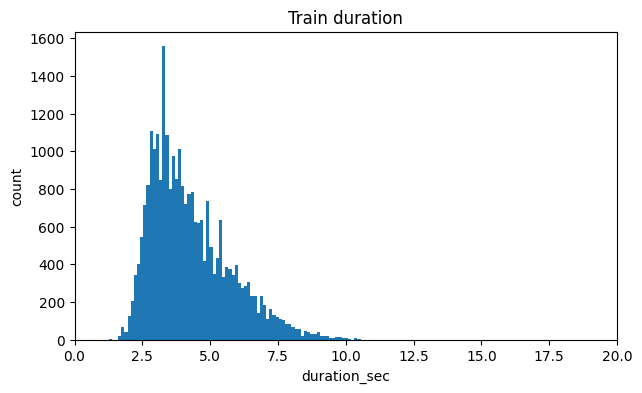

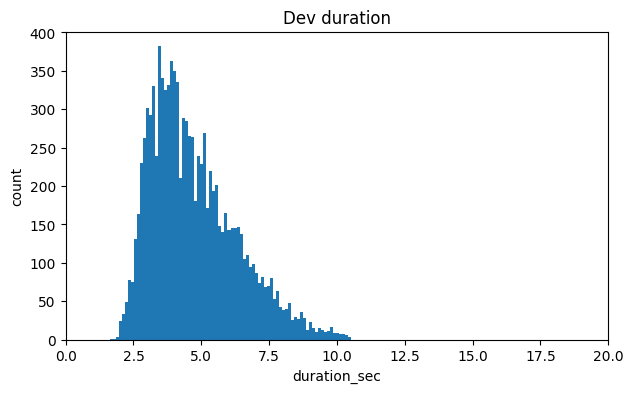

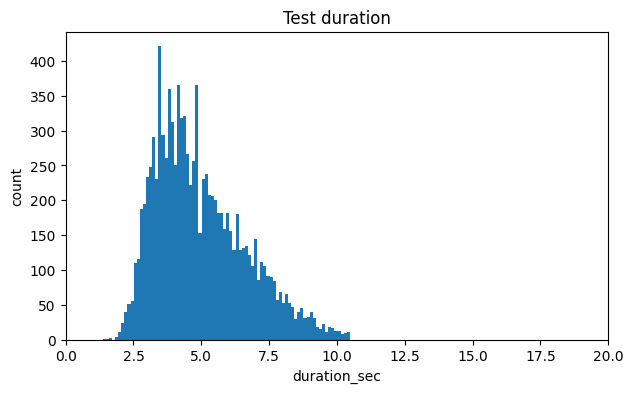

In [54]:
def plot_duration_hist(df, title, bins=80, xlim=(0, 20)):
    s = df["duration_sec"].dropna()
    plt.figure(figsize=(7,4))
    plt.hist(s, bins=bins)
    plt.title(title)
    plt.xlabel("duration_sec")
    plt.ylabel("count")
    if xlim: plt.xlim(*xlim)
    plt.show()

plot_duration_hist(train_p, "Train duration", xlim=(0, 20))
plot_duration_hist(dev_p, "Dev duration", xlim=(0, 20))
plot_duration_hist(test_p, "Test duration", xlim=(0, 20))

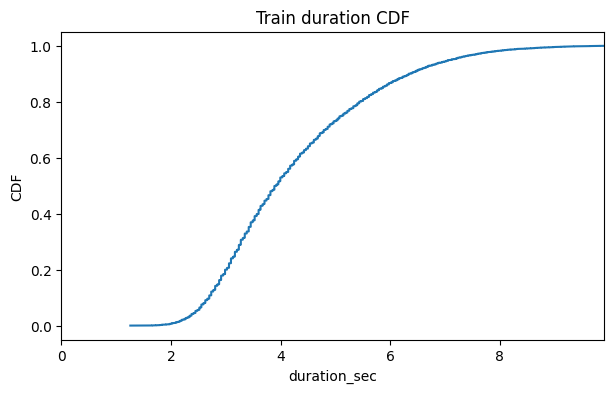

In [55]:
def plot_duration_cdf(df, title):
    s = np.sort(df["duration_sec"].dropna().values)
    y = np.arange(1, len(s)+1) / len(s)
    plt.figure(figsize=(7,4))
    plt.plot(s, y)
    plt.title(title)
    plt.xlabel("duration_sec")
    plt.ylabel("CDF")
    plt.xlim(0, min(60, float(np.quantile(s, 0.999))))
    plt.show()

plot_duration_cdf(train_p, "Train duration CDF")

In [60]:
# outliers
display(train_p.sort_values("duration_sec").head(10)[["path","duration_sec","sample_rate","n_channels"]])
display(train_p.sort_values("duration_sec", ascending=False).head(10)[["path","duration_sec","sample_rate","n_channels"]])

,path,duration_sec,sample_rate,n_channels
25299,common_voice_uk_29049860.mp3,1.260,32000.0,1.0
17615,common_voice_uk_27464977.mp3,1.620,32000.0,1.0
16769,common_voice_uk_27250654.mp3,1.620,32000.0,1.0
17720,common_voice_uk_27465868.mp3,1.620,32000.0,1.0
17244,common_voice_uk_27314366.mp3,1.620,32000.0,1.0
17365,common_voice_uk_27448063.mp3,1.620,32000.0,1.0
17840,common_voice_uk_27480855.mp3,1.620,32000.0,1.0
11365,common_voice_uk_28697660.mp3,1.656,32000.0,1.0
17765,common_voice_uk_27480487.mp3,1.656,32000.0,1.0
2299,common_voice_uk_21595624.mp3,1.656,48000.0,1.0


,path,duration_sec,sample_rate,n_channels
11014,common_voice_uk_28689212.mp3,10.548,32000.0,1.0
3879,common_voice_uk_23934090.mp3,10.416,48000.0,1.0
1915,common_voice_uk_23561095.mp3,10.416,48000.0,1.0
4950,common_voice_uk_27627029.mp3,10.404,32000.0,1.0
6729,common_voice_uk_28182186.mp3,10.368,32000.0,1.0
2530,common_voice_uk_28482747.mp3,10.368,32000.0,1.0
1893,common_voice_uk_23560757.mp3,10.344,48000.0,1.0
24808,common_voice_uk_28011033.mp3,10.188,32000.0,1.0
3881,common_voice_uk_23934093.mp3,10.176,48000.0,1.0
2791,common_voice_uk_23664824.mp3,10.104,48000.0,1.0


,split,dur_bin,n_utt,share_%,total_hours
0,train,0-2,168,0.620980,0.086467
1,train,2-4,14141,52.269535,12.491023
2,train,4-6,9120,33.710357,12.358469
3,train,6-8,3122,11.539883,5.872500
4,train,8-10,486,1.796407,1.170663
5,train,10-12,17,0.062837,0.048247
6,dev,0-2,13,0.126299,0.006950
7,dev,2-4,4094,39.774604,3.738782
8,dev,4-6,4061,39.453998,5.514582
9,dev,6-8,1691,16.428641,3.199406


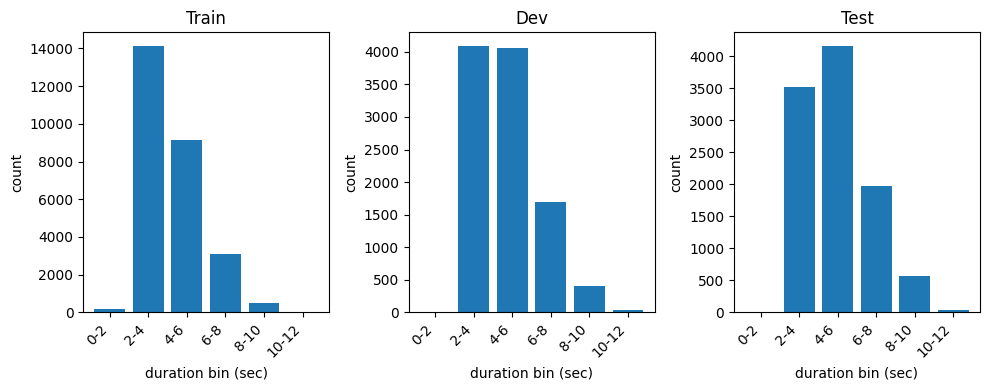

In [67]:
BINS = [0, 2, 4, 6, 8, 10, 12, np.inf]
LABELS = ["0-2", "2-4", "4-6", "6-8", "8-10", "10-12", "12+"]

def duration_bin_table(df: pd.DataFrame, name: str) -> pd.DataFrame:
    d = df.copy()
    d = d[d["probe_ok"]].copy()
    d["dur_bin"] = pd.cut(d["duration_sec"], bins=BINS, labels=LABELS, right=False, include_lowest=True)

    agg = (
        d.groupby("dur_bin", observed=True)["duration_sec"]
        .agg(n_utt="count", total_sec="sum")
        .reset_index()
    )
    agg["total_hours"] = agg["total_sec"] / 3600.0
    agg["share_%"] = 100.0 * agg["n_utt"] / agg["n_utt"].sum()
    agg.insert(0, "split", name)
    return agg[["split", "dur_bin", "n_utt", "share_%", "total_hours"]]

train_bins = duration_bin_table(train_p, "train")
dev_bins   = duration_bin_table(dev_p, "dev")
test_bins  = duration_bin_table(test_p, "test")

display(pd.concat([train_bins, dev_bins, test_bins], ignore_index=True))

x_labels = train_bins["dur_bin"].astype(str).tolist()
x = range(len(x_labels))

plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.bar(x, train_bins["n_utt"].values)
plt.title("Train")
plt.xlabel("duration bin (sec)")
plt.ylabel("count")
plt.xticks(list(x), x_labels, rotation=45, ha="right")

plt.subplot(1, 3, 2)
plt.bar(x, dev_bins["n_utt"].values)
plt.title("Dev")
plt.xlabel("duration bin (sec)")
plt.ylabel("count")
plt.xticks(list(x), x_labels, rotation=45, ha="right")

plt.subplot(1, 3, 3)
plt.bar(x, test_bins["n_utt"].values)
plt.title("Test")
plt.xlabel("duration bin (sec)")
plt.ylabel("count")
plt.xticks(list(x), x_labels, rotation=45, ha="right")

plt.tight_layout()
plt.show()

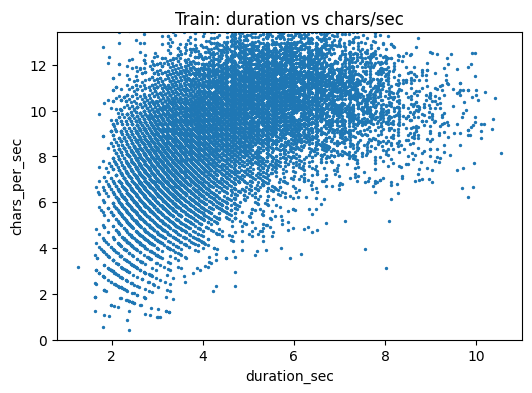

In [68]:
# text length vs audio duration
def add_rate_cols(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["chars_per_sec"] = df["n_chars"] / df["duration_sec"]
    df["words_per_sec"] = df["n_words"] / df["duration_sec"]
    return df

train_p = add_rate_cols(train_p)
test_p  = add_rate_cols(test_p)
if len(dev_df): dev_p = add_rate_cols(dev_p)

def plot_scatter(df, title, n=20000):
    d = df.dropna(subset=["duration_sec","chars_per_sec"])
    if len(d) > n:
        d = d.sample(n, random_state=0)
    plt.figure(figsize=(6,4))
    plt.scatter(d["duration_sec"], d["chars_per_sec"], s=2)
    plt.title(title)
    plt.xlabel("duration_sec")
    plt.ylabel("chars_per_sec")
    plt.ylim(0, np.nanpercentile(d["chars_per_sec"], 99))
    plt.show()

plot_scatter(train_p, "Train: duration vs chars/sec")

In [69]:
train_p.sort_values("chars_per_sec", ascending=False)[
    ["path","duration_sec","n_chars","chars_per_sec","sentence_norm"]
].head(10)

,path,duration_sec,n_chars,chars_per_sec,sentence_norm
9425,common_voice_uk_37815234.mp3,3.456,56,16.203704,по обіді ми всією громадою подались правим бер...
26040,common_voice_uk_33076364.mp3,4.284,68,15.873016,справді в одній з кишень лежав електричний ліх...
2297,common_voice_uk_21595600.mp3,5.856,92,15.710383,прем'єр міністр україни призначається верховно...
1194,common_voice_uk_21565832.mp3,7.464,116,15.541265,моральний кодекс свідомого громадянина розпочи...
6921,common_voice_uk_27962217.mp3,7.668,119,15.519040,після здобуття незалежності україною коротка х...
9164,common_voice_uk_37814183.mp3,3.168,49,15.467172,через що ж ця зла несподівана брутальність до неї
8792,common_voice_uk_37809643.mp3,4.788,74,15.455305,ми трохи не скрикнули всі з переляку і в одній...
23716,common_voice_uk_27216210.mp3,5.436,84,15.452539,та в тому ж таки торонто інший іммігрант поясн...
7249,common_voice_uk_28012374.mp3,6.876,106,15.415939,закликав щоб вступали добровольцями до його за...
8713,common_voice_uk_37809489.mp3,4.500,69,15.333333,такий колір бачимо коли дивимося на нього кріз...


In [75]:
# duplicate transcripts
dup = train_p["sentence_norm"].value_counts()
print("Unique normalized transcripts:", (dup > 0).sum())
print("Transcripts that repeat >=2 times:", (dup >= 2).sum())
print("Transcripts that repeat >=5 times:", (dup >= 5).sum())
dup.head(10)

Unique normalized transcripts: 27027
Transcripts that repeat >=2 times: 27
Transcripts that repeat >=5 times: 0


,count
sentence_norm,
трьох,2
а,2
так і жили ми собі,2
частина третя,2
землю піп здав селянам у полі роботи зовсім не було,2
ви комуніст,2
мовчи глуха менше гріха,2
це неможливо,2
парубок витерши очі підсунув його трошки ближче до себе,2
